III.A Extract & Prep

In [3]:
import pandas as pd
from google.colab import files

# Upload the file you just saved
uploaded = files.upload()

# Load it into a dataframe using the '|' separator
df = pd.read_csv('family_descriptions (1).csv', sep='|')

# Show the first few rows to verify
print(f"Dataset contains {df.shape[0]} families.")
df.head()

Saving family_descriptions (1).csv to family_descriptions (1) (2).csv
Dataset contains 10 families.


,FamilyName,Description
0,Asteraceae,"The Asteraceae family, commonly known as the a..."
1,Rosaceae,Rosaceae is a medium-sized family of flowering...
2,Liliaceae,"Liliaceae consists of monocotyledonous, perenn..."
3,Orchidaceae,Orchidaceae is a diverse and widespread family...
4,Iridaceae,Iridaceae is a family of plants in the order A...


III.B IPYNB Text Mining

In [4]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

def preprocess_text(text):
    text = text.lower() # Lowercasing
    text = re.sub(r'[^\w\s]', '', text) # Removing punctuation

    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [w for w in words if w not in stop_words] #Stop-word removal

    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(w) for w in words] #Lemmatization

    return " ".join(words)

df['Cleaned_Description'] = df['Description'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [5]:
from sklearn.feature_extraction.text import CountVectorizer

# Unigram TDM (Single words)
vectorizer_uni = CountVectorizer(ngram_range=(1, 1))
tdm_uni = vectorizer_uni.fit_transform(df['Cleaned_Description'])
print(f"Unigram TDM Dimensions: {tdm_uni.shape}")

# Bigram TDM (Two-word phrases)
vectorizer_bi = CountVectorizer(ngram_range=(2, 2))
tdm_bi = vectorizer_bi.fit_transform(df['Cleaned_Description'])
print(f"Bigram TDM Dimensions: {tdm_bi.shape}")

Unigram TDM Dimensions: (10, 112)
Bigram TDM Dimensions: (10, 145)


In [6]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate similarity
similarity_matrix = cosine_similarity(tdm_uni)
sim_df = pd.DataFrame(similarity_matrix, index=df['FamilyName'], columns=df['FamilyName'])

# Display results for Asteraceae
print(sim_df['Asteraceae'].sort_values(ascending=False))

FamilyName
Asteraceae       1.000000
Orchidaceae      0.455150
Fabaceae         0.455150
Papaveraceae     0.445132
Ranunculaceae    0.433861
Lamiaceae        0.433861
Rosaceae         0.294118
Iridaceae        0.222566
Boraginaceae     0.176471
Liliaceae        0.057166
Name: Asteraceae, dtype: float64


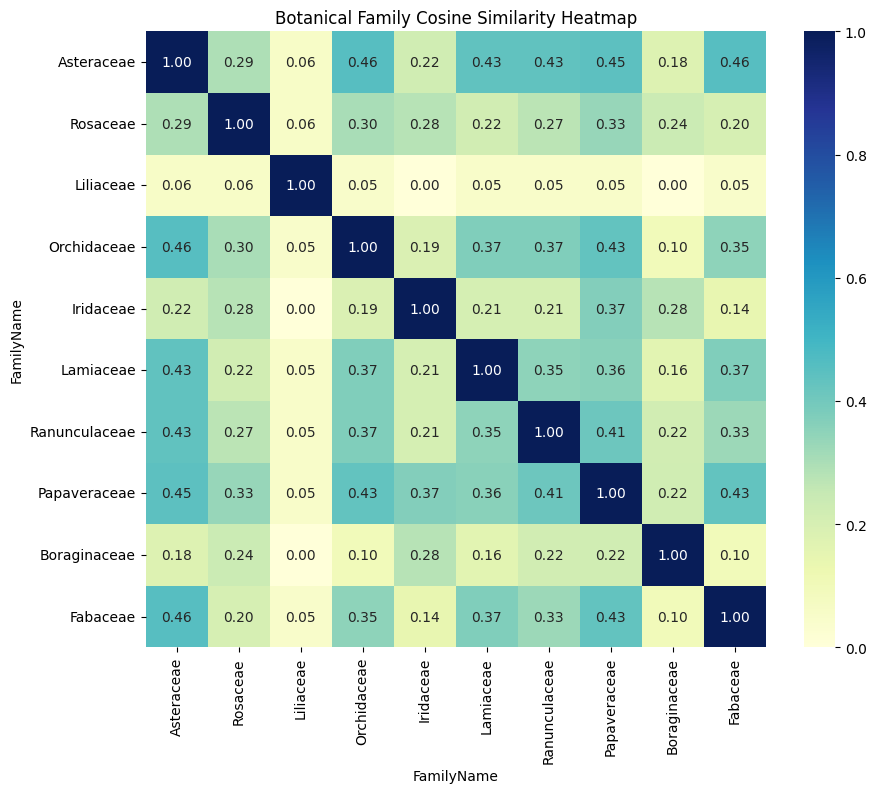

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the size of the plot
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(sim_df, annot=True, cmap='YlGnBu', fmt=".2f")

# Add a title
plt.title('Botanical Family Cosine Similarity Heatmap')

# SAVE the image so you can download it
plt.savefig('similarity_heatmap.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Part IV: Self-Assessment & Perspective

**Critical Reflection**
1.   **Data Limitations:**
*   My synthetic data has very small entry points compared to a company/ industry would actually have. While this helps keep the file size manegable and easy to transfer from XML to JSON to CSV, the conversions would be different with a larger dataset. I would not recommend keeping all tables in one file in JSON, multiple files will make Querries easier and cleaner.
*   My Cosine Similarity scores are also quite high and low because the vocabulary is limited in a small sample size. A real database would have more complex term-document matrices.
*   With the use of AI to create the data, it doesnt reflect a real companies data points as companies would have multiple customers per one store times all the stores city wide/ provincewide/ country wide/ world wide. This would enrich the database and give more information to make strategic decisions for the company.

2.   **Ethics and Privacy:**

*   The customer's identity must be protected before this pipeline could process real customers' data and shops' data. Instead of identifying them by name, they should just have a customer ID number.
*   Ethical concern come in the form of making sure the customer has cosented to have their data be used by the company, with this there needs to be levels of authorization to the information. Not every employee at the company needs access to all the information. It is importnat to limit it to those who needed and will be trusted to keep the information confidential.

3.   **Stakeholder Impact:**


*   The business team's day to day would be affected by having to gain permission to access certain information from the database from a superior. While this creates a slow down in the flow of information, it is important to mantaining privacy. The sales  force team might also have to put a sign at the store or on the receipt that explains that shopping at the store gives the store consent to use their data for analysis and how it will be protected.
*   Knowing the biases and limitations, the team must make sure that the entries into the database are accurate, complete, and clean to make sure the results are precise and useful to the company.

4.   **Technical Reflection:**

*   If I had to build this project again, i would like to make the raw data more complex and really test its ability to give accurate results to prepare for real world scenarios. I would add more customer's per store and change the georaphical location from cities around the world to all the stores being within Ontario, so that the project can go into predictive modeling from here, whether it is looking for the optmial neighbourhood to place a new store or the ideal segment to focus on.
*   When it comes to the JSON file, I would like it to be multiple files, each with their own table so that I don't have all the information in one single document.